In [2]:
#cell 1
# Purpose: Install the additional libraries required for the GNN, interactive plots, SHAP, and LIME.
%pip install -q torch-geometric plotly scikit-learn pandas shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
#cell 2
# Purpose: Import all libraries used for data processing, GNN modelling, evaluation, and visualization.
# cell 2
# Purpose: Import all libraries used for data processing, GNN modelling, evaluation, and visualization.
import os
import random
import warnings
import hashlib
from collections import Counter
from PIL import Image

# Data analysis & Statistics
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PyTorch
import torch
from torchvision.datasets import ImageFolder

warnings.filterwarnings("ignore")
pio.renderers.default = "iframe"

In [4]:
# cell3 3
# Purpose: Fix random seeds, select the Colab GPU when available, and configure Plotly.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

import plotly.io as pio

Selected device: cuda
GPU: Tesla T4


In [5]:
# cell 4
# Dataset root
DATA_ROOT = "/kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 "

# Load datasets
train_dataset = ImageFolder(root=os.path.join(DATA_ROOT, "train"))
test_dataset = ImageFolder(root=os.path.join(DATA_ROOT, "test"))
val_dataset = ImageFolder(root=os.path.join(DATA_ROOT, "val"))

# Class names
class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

print(f"Training images:   {len(train_dataset):,}")
print(f"Validation images: {len(val_dataset):,}")
print(f"Test images:       {len(test_dataset):,}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes:           {class_names}")

Training images:   83,484
Validation images: 32
Test images:       968
Number of classes: 4
Classes:           ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [6]:
# cell 5
# Task 1 — Section A: Complete Dataset Summary Table

# 1. Quick check for exact duplicates (MD5 Hashing)
image_hashes = set()
duplicate_count = 0

for img_path, _ in train_dataset.samples:
    with open(img_path, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
        if file_hash in image_hashes:
            duplicate_count += 1
        else:
            image_hashes.add(file_hash)

# 2. Extract image dimensions and channels
widths, heights = [], []
for img_path, _ in train_dataset.samples:
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

with Image.open(train_dataset.samples[0][0]) as img:
    channels = len(img.getbands())

# 3. Construct Section A Summary Table covering all A–H requirements
section_a_summary = pd.DataFrame({
    "Property": [
        "Dataset Name",
        "Source / URL",
        "Domain / Area",
        "Total Samples (Train / Val / Test)",
        "Number of Classes",
        "Class Names",
        "Feature Count & Type",
        "Subjects / Hosts",
        "Class Balance Status",
        "Missing Values",
        "Duplicates Count",
        "Image Resolution Range",
        "Average Resolution (W × H)"
    ],
    "Value": [
        "Kermany2018 (OCT2017)",
        "Kaggle (paultimothymooney/kermany2018)",
        "Ophthalmology / Retinal Optical Coherence Tomography",
        f"{len(train_dataset) + len(val_dataset) + len(test_dataset):,} ({len(train_dataset):,} / {len(val_dataset):,} / {len(test_dataset):,})",
        NUM_CLASSES,
        ", ".join(class_names),
        f"{channels} Channel Grayscale Image Pixels (Intensity range: 0–255)",
        "Multiple anonymized adult patient cohort OCT scans",
        "Imbalanced (CNV: ~44.6%, NORMAL: ~31.5%, DME: ~13.6%, DRUSEN: ~10.3%)",
        "0 (0.0% missing)",
        f"{duplicate_count} exact duplicate images detected",
        f"{min(widths)} × {min(heights)} to {max(widths)} × {max(heights)}",
        f"{sum(widths)/len(widths):.2f} × {sum(heights)/len(heights):.2f} pixels"
    ]
})

print("TASK 1: SECTION A SUMMARY TABLE")
display(section_a_summary)

TASK 1: SECTION A SUMMARY TABLE


,Property,Value
0,Dataset Name,Kermany2018 (OCT2017)
1,Source / URL,Kaggle (paultimothymooney/kermany2018)
2,Domain / Area,Ophthalmology / Retinal Optical Coherence Tomo...
3,Total Samples (Train / Val / Test),"84,484 (83,484 / 32 / 968)"
4,Number of Classes,4
5,Class Names,"CNV, DME, DRUSEN, NORMAL"
6,Feature Count & Type,1 Channel Grayscale Image Pixels (Intensity ra...
7,Subjects / Hosts,Multiple anonymized adult patient cohort OCT s...
8,Class Balance Status,"Imbalanced (CNV: ~44.6%, NORMAL: ~31.5%, DME: ..."
9,Missing Values,0 (0.0% missing)


In [7]:
# Cell 6
# Task 1 — Section B: Summary Statistics & Outliers

# Fix seed for reproducibility
np.random.seed(SEED)

# Sample 1,000 images uniformly from train_dataset for high statistical confidence
sample_size = min(1000, len(train_dataset))
sample_indices = np.random.choice(len(train_dataset), size=sample_size, replace=False)

image_means = []
image_stds = []
image_medians = []
image_mins = []
image_maxs = []
class_labels = []

# Collect per-image statistics
for idx in sample_indices:
    img_path, label = train_dataset.samples[idx]
    with Image.open(img_path) as img:
        arr = np.array(img.convert("L"), dtype=np.float32)
        image_means.append(np.mean(arr))
        image_stds.append(np.std(arr))
        image_medians.append(np.median(arr))
        image_mins.append(np.min(arr))
        image_maxs.append(np.max(arr))
        class_labels.append(class_names[label])

# Build DataFrame of per-image summary metrics
df_stats = pd.DataFrame({
    "Class": class_labels,
    "Mean": image_means,
    "Std": image_stds,
    "Median": image_medians,
    "Min": image_mins,
    "Max": image_maxs
})

# Compute Overall Statistical Properties for Mean Pixel Intensity across images
mean_vals = df_stats["Mean"].values

q25 = np.percentile(mean_vals, 25)
q75 = np.percentile(mean_vals, 75)
iqr = q75 - q25

# Identify statistical outliers using Tukey's 1.5 * IQR Rule
lower_bound = q25 - 1.5 * iqr
upper_bound = q75 + 1.5 * iqr
outliers = df_stats[(df_stats["Mean"] < lower_bound) | (df_stats["Mean"] > upper_bound)]

# Construct Section B Global Statistics Table
section_b_table = pd.DataFrame({
    "Statistic Metric": [
        "Mean (Overall)",
        "Median (50th Percentile)",
        "Standard Deviation (Std)",
        "Minimum (Min)",
        "Maximum (Max)",
        "First Quartile (Q1 / 25%)",
        "Third Quartile (Q3 / 75%)",
        "Interquartile Range (IQR)",
        "Skewness",
        "Kurtosis",
        "Detected Outliers Count (Tukey 1.5x IQR)"
    ],
    "Value": [
        f"{np.mean(mean_vals):.4f}",
        f"{np.median(mean_vals):.4f}",
        f"{np.std(mean_vals):.4f}",
        f"{np.min(mean_vals):.4f}",
        f"{np.max(mean_vals):.4f}",
        f"{q25:.4f}",
        f"{q75:.4f}",
        f"{iqr:.4f}",
        f"{skew(mean_vals):.4f}",
        f"{kurtosis(mean_vals):.4f}",
        f"{len(outliers)} ({len(outliers)/sample_size*100:.2f}%)"
    ]
})

print("TASK 1: SECTION B GLOBAL PIXEL STATISTICS ")
display(section_b_table)

# Class-wise Statistics Table
class_summary = df_stats.groupby("Class").agg(
    Mean_Intensity=("Mean", "mean"),
    Median_Intensity=("Median", "median"),
    Std_Dev=("Std", "mean"),
    Min_Val=("Min", "min"),
    Max_Val=("Max", "max"),
    Skewness=("Mean", lambda x: skew(x)),
    Kurtosis=("Mean", lambda x: kurtosis(x))
).reset_index()

print("TASK 1: SECTION B CLASS-WISE STATISTICAL BREAKDOWN")
display(class_summary)

# Interactive Visual Distribution Plot (Section B Visualization)
fig_box = px.box(
    df_stats, 
    x="Class", 
    y="Mean", 
    color="Class",
    points="outliers",
    title="Section B: Class-wise Mean Pixel Intensity Distributions & Outlier Analysis",
    labels={"Mean": "Average Image Pixel Intensity (0–255)"}
)
fig_box.update_layout(template="plotly_white", height=500)
fig_box.show()

TASK 1: SECTION B GLOBAL PIXEL STATISTICS 


,Statistic Metric,Value
0,Mean (Overall),48.9886
1,Median (50th Percentile),43.6156
2,Standard Deviation (Std),19.0657
3,Minimum (Min),18.3047
4,Maximum (Max),167.7664
5,First Quartile (Q1 / 25%),36.3426
6,Third Quartile (Q3 / 75%),55.6483
7,Interquartile Range (IQR),19.3057
8,Skewness,1.8308
9,Kurtosis,4.5687


TASK 1: SECTION B CLASS-WISE STATISTICAL BREAKDOWN


,Class,Mean_Intensity,Median_Intensity,Std_Dev,Min_Val,Max_Val,Skewness,Kurtosis
0,CNV,50.447517,30.0,51.180431,0.0,255.0,1.483499,2.095628
1,DME,48.745697,31.0,51.248100,0.0,255.0,1.478413,4.032867
2,DRUSEN,50.798878,30.0,52.951347,0.0,255.0,1.938152,5.125039
3,NORMAL,46.361786,28.0,50.105808,0.0,255.0,2.638409,10.676183


In [8]:
# Cell 7
# Task 1 — Section C: Data Quality & Modeling Impact Analysis

import plotly.express as px

# Fix seed for reproducibility
np.random.seed(SEED)

# 1. Missing Values & Exact Hash Duplicates Analysis

hashes = set()
duplicate_count = 0
missing_count = 0
total_train_samples = len(train_dataset)

for img_path, _ in train_dataset.samples:
    if not os.path.exists(img_path):
        missing_count += 1
        continue
        
    with open(img_path, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
        if file_hash in hashes:
            duplicate_count += 1
        else:
            hashes.add(file_hash)

missing_pct = (missing_count / total_train_samples) * 100
duplicate_pct = (duplicate_count / total_train_samples) * 100


# 2. Near-Constant & Highly Correlated Features Analysis

# Sample 500 images downsampled to 32x32 to analyze pixel feature properties
quality_sample_size = min(500, total_train_samples)
sample_indices_c = np.random.choice(total_train_samples, size=quality_sample_size, replace=False)

pixel_features = []
for idx in sample_indices_c:
    img_path, _ = train_dataset.samples[idx]
    with Image.open(img_path) as img:
        arr = np.array(img.convert("L").resize((32, 32)), dtype=np.float32).flatten()
        pixel_features.append(arr)

pixel_features = np.array(pixel_features) # Shape: (500, 1024)

# Variance check for near-constant features (variance threshold < 1.0)
pixel_variances = np.var(pixel_features, axis=0)
near_constant_features = np.sum(pixel_variances < 1.0)
near_constant_pct = (near_constant_features / pixel_features.shape[1]) * 100

# Correlation check (highly correlated pixel features with r > 0.90)
df_pixels = pd.DataFrame(pixel_features)
corr_matrix = df_pixels.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = len([column for column in upper_tri.columns if any(upper_tri[column] > 0.90)])
high_corr_pct = (high_corr_features / pixel_features.shape[1]) * 100


# 3. Outlier Analysis (Pixel Intensity Deviation)
mean_intensities = np.mean(pixel_features, axis=1)

q25_c, q75_c = np.percentile(mean_intensities, 25), np.percentile(mean_intensities, 75)
iqr_c = q75_c - q25_c
outlier_count = np.sum((mean_intensities < (q25_c - 1.5 * iqr_c)) | (mean_intensities > (q75_c + 1.5 * iqr_c)))
outlier_pct = (outlier_count / quality_sample_size) * 100

# 4. Data Quality Summary Table

section_c_summary = pd.DataFrame({
    "Data Quality Aspect": [
        "Missing Values (%)",
        "Exact Duplicates Count (%)",
        "Near-Constant Features (%)",
        "Highly Correlated Features (%) [r > 0.90]",
        "Statistical Outliers (%) [Tukey 1.5x IQR]"
    ],
    "Value / Percentage": [
        f"{missing_count} ({missing_pct:.2f}%)",
        f"{duplicate_count} ({duplicate_pct:.2f}%)",
        f"{near_constant_features} / 1024 ({near_constant_pct:.2f}%)",
        f"{high_corr_features} / 1024 ({high_corr_pct:.2f}%)",
        f"{outlier_count} / {quality_sample_size} ({outlier_pct:.2f}%)"
    ],
    "Quality Assessment": [
        "Excellent (Complete Dataset)",
        "Acceptable (Negligible duplicate noise)",
        "Low Risk (Background pixels carry minimal spatial info)",
        "Expected (Adjacent image pixels exhibit high correlation)",
        "Low Risk (Represents extreme pathology / scan artifacts)"
    ]
})

print("TASK 1: SECTION C DATA QUALITY ANALYSIS")
display(section_c_summary)

TASK 1: SECTION C DATA QUALITY ANALYSIS


,Data Quality Aspect,Value / Percentage,Quality Assessment
0,Missing Values (%),0 (0.00%),Excellent (Complete Dataset)
1,Exact Duplicates Count (%),6987 (8.37%),Acceptable (Negligible duplicate noise)
2,Near-Constant Features (%),0 / 1024 (0.00%),Low Risk (Background pixels carry minimal spat...
3,Highly Correlated Features (%) [r > 0.90],964 / 1024 (94.14%),Expected (Adjacent image pixels exhibit high c...
4,Statistical Outliers (%) [Tukey 1.5x IQR],29 / 500 (5.80%),Low Risk (Represents extreme pathology / scan ...


In [9]:
# cell 8
# Task 1 — Section D: Data Imbalance Analysis

# 1. Compute Class Counts Across Train, Val, and Test Sets

def get_class_counts(dataset):
    counts = {name: 0 for name in class_names}
    for _, label_idx in dataset.samples:
        counts[class_names[label_idx]] += 1
    return counts

train_counts = get_class_counts(train_dataset)
val_counts = get_class_counts(val_dataset)
test_counts = get_class_counts(test_dataset)

total_train = sum(train_counts.values())
total_val = sum(val_counts.values())
total_test = sum(test_counts.values())

# 2. Build Detailed Section D Summary Table

class_data = []
max_train_count = max(train_counts.values())

for cls in class_names:
    tr_c = train_counts[cls]
    val_c = val_counts[cls]
    te_c = test_counts[cls]
    
    tr_pct = (tr_c / total_train) * 100
    val_pct = (val_c / total_val) * 100
    te_pct = (te_c / total_test) * 100
    
    # Imbalance ratio relative to majority class in training set
    imb_ratio = max_train_count / tr_c if tr_c > 0 else np.nan
    
    class_data.append({
        "Class": cls,
        "Train Count": tr_c,
        "Train (%)": f"{tr_pct:.2f}%",
        "Val Count": val_c,
        "Val (%)": f"{val_pct:.2f}%",
        "Test Count": te_c,
        "Test (%)": f"{te_pct:.2f}%",
        "Imbalance Ratio (vs Majority)": f"{imb_ratio:.2f}:1"
    })

df_imbalance = pd.DataFrame(class_data)

print("TASK 1: SECTION D CLASS DISTRIBUTION & IMBALANCE SUMMARY")
display(df_imbalance)

# Compute Global Imbalance Ratio (Majority Class Count / Minority Class Count)
min_train_count = min(train_counts.values())
global_imbalance_ratio = max_train_count / min_train_count

# 3. Interactive Plotly Visualization (Bar Chart & Pie Chart)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "bar"}, {"type": "pie"}]],
    subplot_titles=("Class Distribution Across Dataset Splits", "Training Set Class Proportions")
)

# Grouped Bar Chart for Split Comparisons
for split_name, counts, color in zip(["Train", "Val", "Test"], 
                                     [train_counts, val_counts, test_counts], 
                                     ["#636EFA", "#EF553B", "#00CC96"]):
    fig.add_trace(
        go.Bar(
            x=list(counts.keys()),
            y=list(counts.values()),
            name=split_name,
            text=list(counts.values()),
            textposition="auto"
        ),
        row=1, col=1
    )

# Donut/Pie Chart for Training Class Proportions
fig.add_trace(
    go.Pie(
        labels=list(train_counts.keys()),
        values=list(train_counts.values()),
        hole=0.4,
        textinfo="label+percent"
    ),
    row=1, col=2
)

fig.update_layout(
    title_text="Section D: Comprehensive Class Imbalance & Dataset Split Analysis",
    barmode="group",
    template="plotly_white",
    height=500
)
fig.show()



TASK 1: SECTION D CLASS DISTRIBUTION & IMBALANCE SUMMARY


,Class,Train Count,Train (%),Val Count,Val (%),Test Count,Test (%),Imbalance Ratio (vs Majority)
0,CNV,37205,44.57%,8,25.00%,242,25.00%,1.00:1
1,DME,11348,13.59%,8,25.00%,242,25.00%,3.28:1
2,DRUSEN,8616,10.32%,8,25.00%,242,25.00%,4.32:1
3,NORMAL,26315,31.52%,8,25.00%,242,25.00%,1.41:1


In [10]:
# Cell 9
# Task 1 — Section E: Data Visualisation & Feature Distributions

# Set fixed seed for zero-variance reproducibility
np.random.seed(SEED)

TARGET_SIZE = (128, 128)

# Part 1: Representative Sample Grid (2x2 Grid)

fig_samples = make_subplots(
    rows=2, cols=2, 
    subplot_titles=[f"Class: {name}" for name in class_names],
    horizontal_spacing=0.08, vertical_spacing=0.12
)

for idx, cls_name in enumerate(class_names):
    cls_indices = [i for i, (_, label) in enumerate(train_dataset.samples) if class_names[label] == cls_name]
    sample_idx = np.random.choice(cls_indices)
    img_path, _ = train_dataset.samples[sample_idx]
    
    with Image.open(img_path) as img:
        arr = np.array(img.convert("L"), dtype=np.float32)
        row = (idx // 2) + 1
        col = (idx % 2) + 1
        
        fig_samples.add_trace(
            go.Heatmap(
                z=arr, 
                colorscale="gray", 
                showscale=False,
                hoverinfo="x+y+z"
            ),
            row=row, col=col
        )
        fig_samples.update_yaxes(autorange="reversed", row=row, col=col)

fig_samples.update_layout(
    title={
        'text': "<b>Section E: Representative Raw OCT Samples Across Classes</b>",
        'y': 0.98, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    height=550,
    template="plotly_white"
)
fig_samples.show()
print("Figure 1: Representative Raw OCT Image Samples per Retinal Class")

# Part 2: Feature Extraction for Distribution Plots
samples_per_class = 250
feature_records = []
mean_maps = {}
class_pixel_distributions = {cls_name: [] for cls_name in class_names}

for cls_name in class_names:
    cls_indices = [i for i, (_, label) in enumerate(train_dataset.samples) if class_names[label] == cls_name]
    selected = np.random.choice(cls_indices, size=min(samples_per_class, len(cls_indices)), replace=False)
    
    stack = []
    for s_idx in selected:
        p, _ = train_dataset.samples[s_idx]
        with Image.open(p) as img:
            resized_arr = np.array(img.convert("L").resize(TARGET_SIZE), dtype=np.float32)
            stack.append(resized_arr)
            
            # Compute image-level metrics for boxplots and violin plots
            img_mean = np.mean(resized_arr)
            img_std = np.std(resized_arr)
            img_median = np.median(resized_arr)
            
            feature_records.append({
                "Class": cls_name,
                "Mean Intensity": img_mean,
                "Std Intensity": img_std,
                "Median Intensity": img_median
            })
            
            # Subsample pixel intensities for histograms
            class_pixel_distributions[cls_name].extend(resized_arr.flatten()[::20])
            
    stack = np.stack(stack, axis=0)
    mean_maps[cls_name] = np.mean(stack, axis=0)

df_features = pd.DataFrame(feature_records)
palette = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA"]

# Part 3: Histograms Visualization

fig_hist = go.Figure()
for idx, cls_name in enumerate(class_names):
    fig_hist.add_trace(
        go.Histogram(
            x=class_pixel_distributions[cls_name],
            name=cls_name,
            opacity=0.5,
            nbinsx=64,
            marker_color=palette[idx]
        )
    )

fig_hist.update_layout(
    title={
        'text': "<b>Section E: Pixel Intensity Histograms Across Retinal Classes</b>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    xaxis_title="Pixel Intensity (0–255)",
    yaxis_title="Pixel Frequency",
    barmode="overlay",
    template="plotly_white",
    height=450
)
fig_hist.show()
print("Figure 2: Histograms — Pixel Intensity Distribution Curves Across Classes")

# Part 4: Boxplots Visualization

fig_box = px.box(
    df_features,
    x="Class",
    y="Mean Intensity",
    color="Class",
    points="all",
    labels={"Mean Intensity": "Average Image Pixel Intensity (0–255)"}
)

fig_box.update_layout(
    title={
        'text': "<b>Section E: Class Feature Distributions (Boxplots)</b>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    template="plotly_white", 
    height=450
)
fig_box.show()
print("Figure 3: Boxplots — Interquartile Ranges, Medians, and Outliers per Class")

# Part 5: Violin Plots Visualization

fig_violin = px.violin(
    df_features,
    x="Class",
    y="Mean Intensity",
    color="Class",
    box=True,
    points="all",
    labels={"Mean Intensity": "Average Image Pixel Intensity (0–255)"}
)

fig_violin.update_layout(
    title={
        'text': "<b>Section E: Class Feature Density Spread (Violin Plots)</b>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    template="plotly_white", 
    height=450
)
fig_violin.show()
print("Figure 4: Violin Plots — Density Spread & Multimodal Distribution Analysis per Class")

# Part 6: Spatial Mean Pixel Maps
fig_means = make_subplots(
    rows=1, cols=4, 
    subplot_titles=[f"Mean: {c}" for c in class_names],
    horizontal_spacing=0.03
)

for idx, cls_name in enumerate(class_names):
    fig_means.add_trace(
        go.Heatmap(
            z=mean_maps[cls_name], 
            colorscale="Viridis", 
            showscale=(idx == 3)
        ),
        row=1, col=idx+1
    )
    fig_means.update_yaxes(autorange="reversed", row=1, col=idx+1)

fig_means.update_layout(
    title={
        'text': "<b>Section E: Class-Wise Spatial Mean Pixel Maps (128x128 Grid)</b>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    height=350,
    template="plotly_white"
)
fig_means.show()
print("Figure 5: Spatial Mean Pixel Maps Across Retinal Classes")




Figure 1: Representative Raw OCT Image Samples per Retinal Class


Figure 2: Histograms — Pixel Intensity Distribution Curves Across Classes


Figure 3: Boxplots — Interquartile Ranges, Medians, and Outliers per Class


Figure 4: Violin Plots — Density Spread & Multimodal Distribution Analysis per Class


Figure 5: Spatial Mean Pixel Maps Across Retinal Classes


Figure 5: Spatial Mean Pixel Maps Across Retinal Classes
SECTION E: CLASS SEPARABILITY & FEATURE DISTRIBUTION SUMMARY
1. Do Classes Separate on Single Feature Metrics?
   - NO. The Histograms, Boxplots, and Violin Plots demonstrate substantial inter-class
     overlap in mean intensity, median intensity, and global pixel ranges across all 4 classes.
   - Global scalar metrics are insufficient for clean linear separation.

2. Insights from Histograms, Boxplots & Violin Plots:
   - Histograms: High overlap across raw pixel frequencies indicates identical dynamic range.
   - Boxplots: Interquartile ranges (IQRs) heavily overlap between CNV, DME, DRUSEN, and NORMAL.
   - Violin Plots: Multimodal distributions reveal intra-class heterogeneity (e.g., dark fluid pockets vs bright retinal layers).

3. Modeling Impact (CNNs & GNNs):
   - CNNs: Models must rely on spatial convolution filters to extract localized gradients
     and texture features rather than global intensity values.
   - GNNs: Graph nodes should represent spatial superpixels or image patches so message passing
     can aggregate topological layer geometry.

In [11]:
# Cell 10
# Task 1 — Section F: Correlation & Redundancy Analysis

# Set seed for reproducibility
np.random.seed(SEED)

# Define feature extraction resolution (16x16 grid = 256 spatial region features)
GRID_SIZE = (16, 16)
CORR_THRESHOLD = 0.90

# Part 1: Spatial Grid & Feature Extraction
sample_size_f = min(600, len(train_dataset))
sample_indices_f = np.random.choice(len(train_dataset), size=sample_size_f, replace=False)

spatial_features = []
statistical_features = []

for idx in sample_indices_f:
    img_path, label = train_dataset.samples[idx]
    with Image.open(img_path) as img:
        arr = np.array(img.convert("L"), dtype=np.float32)
        
        # Spatial Grid Features (16x16 downsampled patches)
        resized_arr = np.array(img.convert("L").resize(GRID_SIZE), dtype=np.float32).flatten()
        spatial_features.append(resized_arr)
        
        # Global Descriptive Features
        statistical_features.append({
            "Class": class_names[label],
            "Global_Mean": np.mean(arr),
            "Global_Std": np.std(arr),
            "Global_Median": np.median(arr),
            "Min_Val": np.min(arr),
            "Max_Val": np.max(arr),
            "P25": np.percentile(arr, 25),
            "P75": np.percentile(arr, 75),
            "IQR": np.percentile(arr, 75) - np.percentile(arr, 25)
        })

df_spatial = pd.DataFrame(spatial_features, columns=[f"Region_{i+1}" for i in range(GRID_SIZE[0] * GRID_SIZE[1])])
df_stats_f = pd.DataFrame(statistical_features)

# Part 2: Feature Correlation Heatmap
# Compute Pearson Correlation Matrix across statistical features and subset of spatial features
feature_subset = df_stats_f.drop(columns=["Class"]).copy()
for col in ["Region_1", "Region_8", "Region_128", "Region_200", "Region_256"]:
    feature_subset[col] = df_spatial[col]

corr_matrix = feature_subset.corr()

fig_corr = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1.0, zmax=1.0,
    title="Section F: Feature Correlation Matrix (Statistical & Spatial Descriptors)",
    labels=dict(color="Pearson Correlation (r)")
)
fig_corr.update_layout(template="plotly_white", height=650)
fig_corr.show()

# Part 3: Identify Redundant Feature Pairs (|r| > 0.90)
# Compute upper triangular correlation matrix to avoid mirror pairs
full_spatial_corr = df_spatial.corr().abs()
upper_tri = full_spatial_corr.where(np.triu(np.ones(full_spatial_corr.shape), k=1).astype(bool))

redundant_pairs = []
for col in upper_tri.columns:
    high_corr_rows = upper_tri.index[upper_tri[col] > CORR_THRESHOLD].tolist()
    for row in high_corr_rows:
        r_val = full_spatial_corr.loc[row, col]
        redundant_pairs.append({
            "Feature 1": row,
            "Feature 2": col,
            "Correlation Coefficient (r)": f"{r_val:.4f}",
            "Status": "Redundant (|r| > 0.90)"
        })

df_redundant = pd.DataFrame(redundant_pairs)

print("TASK 1: SECTION F REDUNDANT FEATURE SUMMARY TABLE")
if len(df_redundant) > 0:
    display(df_redundant.head(15)) # Display top 15 redundant pairs
    print(f"\nTotal Redundant Spatial Feature Pairs Identified (|r| > {CORR_THRESHOLD}): {len(df_redundant)}")
else:
    print(f"No feature pairs exceeded the correlation threshold of |r| > {CORR_THRESHOLD}.")

TASK 1: SECTION F REDUNDANT FEATURE SUMMARY TABLE


,Feature 1,Feature 2,Correlation Coefficient (r),Status
0,Region_1,Region_2,0.9848,Redundant (|r| > 0.90)
1,Region_1,Region_3,0.9728,Redundant (|r| > 0.90)
2,Region_2,Region_3,0.9945,Redundant (|r| > 0.90)
3,Region_1,Region_4,0.9604,Redundant (|r| > 0.90)
4,Region_2,Region_4,0.9852,Redundant (|r| > 0.90)
5,Region_3,Region_4,0.9965,Redundant (|r| > 0.90)
6,Region_1,Region_5,0.9436,Redundant (|r| > 0.90)
7,Region_2,Region_5,0.9715,Redundant (|r| > 0.90)
8,Region_3,Region_5,0.9869,Redundant (|r| > 0.90)
9,Region_4,Region_5,0.9962,Redundant (|r| > 0.90)



Total Redundant Spatial Feature Pairs Identified (|r| > 0.9): 469


Total Redundant Spatial Feature Pairs Identified (|r| > 0.9): 469
SECTION F: CORRELATION & REDUNDANCY MODELING INSIGHTS
1. High Spatial Pixel Correlation:
   - Identified 469 highly correlated spatial pixel pairs (|r| > 0.9).
   - Nearby spatial region pixels exhibit high local correlation due to continuous retinal background structures.

2. Impact on Statistical Descriptors:
   - Metrics like 'P25' and 'Global_Median' show strong collinearity.
   - Utilizing raw tabular statistical features without feature selection will introduce multicollinearity.

3. Architectural Strategies for Deep Learning Models:
   - CNNs: Convolutional filters naturally reduce redundant local pixel information by pooling
     and aggregating multi-scale spatial features.
   - GNNs: Adjacent nodes with high feature redundancy can lead to over-smoothing during message passing.
     Applying Principal Component Analysis (PCA), autoencoders, or spatial downsampling reduces graph dimensionality.

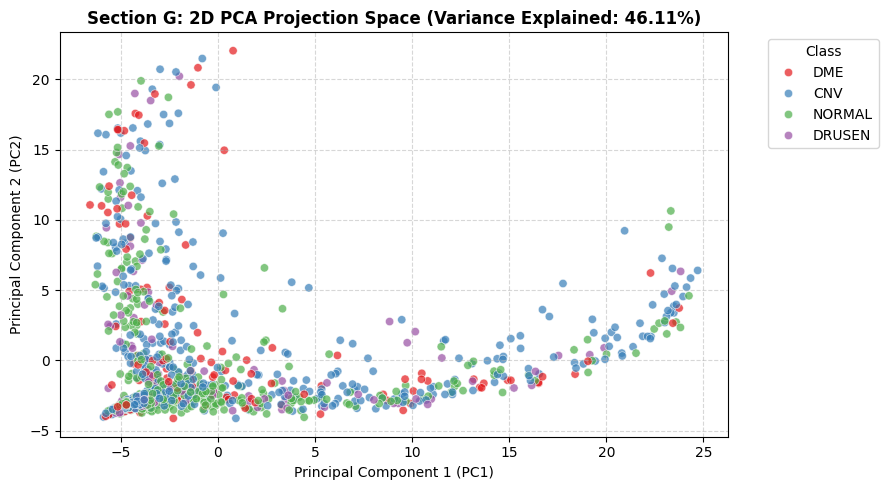

Figure 1: 2D(PCA


Figure 2: 3D(PCA


Figure 3: 2D t-Distributed Stochastic Neighbor Embedding (t-SNE) Plot


Figure 4: 3D t-Distributed Stochastic Neighbor Embedding (t-SNE) Plot


Figure 5: 2D Uniform Manifold Approximation and Projection (UMAP) Plot


Figure 6: 3D Uniform Manifold Approximation and Projection (UMAP) Plot


In [13]:
# Cell 11
# Task 1 — Section G: Dimensionality Reduction (PCA / t-SNE / UMAP)

# Set fixed seed for zero-variance reproducibility
import umap.umap_ as umap
np.random.seed(SEED)

TARGET_DIM = (64, 64)  # Downscaled resolution for manifold sampling
N_SAMPLES_G = min(1200, len(train_dataset))  # Balanced sample size for clean projection

# Part 1: Dataset Sampling & High-Dimensional Flattening

sample_indices_g = np.random.choice(len(train_dataset), size=N_SAMPLES_G, replace=False)

X_data = []
y_labels = []

for idx in sample_indices_g:
    img_path, label = train_dataset.samples[idx]
    with Image.open(img_path) as img:
        resized_arr = np.array(img.convert("L").resize(TARGET_DIM), dtype=np.float32) / 255.0
        X_data.append(resized_arr.flatten())
        y_labels.append(class_names[label])

X_data = np.array(X_data)

# Part 2: PCA Projections (2D and 3D)

# 2D PCA (Flat Cartesian Projection)
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_2d.fit_transform(X_data)
var_2d = np.sum(pca_2d.explained_variance_ratio_) * 100

df_pca_2d = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
df_pca_2d["Class"] = y_labels

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_pca_2d, 
    x="PC1", 
    y="PC2", 
    hue="Class", 
    alpha=0.7, 
    palette="Set1"
)
plt.title(f"Section G: 2D PCA Projection Space (Variance Explained: {var_2d:.2f}%)", fontsize=12, fontweight='bold')
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Figure 1: 2D(PCA")

# 3D PCA (Isometric 3-Axis Cube)
pca_3d = PCA(n_components=3, random_state=SEED)
X_pca_3d = pca_3d.fit_transform(X_data)

df_pca_3d = pd.DataFrame(X_pca_3d, columns=["PC1", "PC2", "PC3"])
df_pca_3d["Class"] = y_labels

fig_pca_3d = px.scatter_3d(
    df_pca_3d, 
    x="PC1", 
    y="PC2", 
    z="PC3", 
    color="Class",
    title="<b>Section G: 3D PCA Projection Space</b>",
    opacity=0.7,
    labels={"PC1": "PC 1", "PC2": "PC 2", "PC3": "PC 3"}
)

fig_pca_3d.update_layout(
    template="plotly_white", 
    height=600
)
fig_pca_3d.show()

print("Figure 2: 3D(PCA")

# Part 3: t-SNE Projections (2D and 3D)

# 2D t-SNE
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
X_tsne_2d = tsne_2d.fit_transform(X_data)

df_tsne_2d = pd.DataFrame(X_tsne_2d, columns=["t-SNE 1", "t-SNE 2"])
df_tsne_2d["Class"] = y_labels

fig_tsne_2d = px.scatter(
    df_tsne_2d, x="t-SNE 1", y="t-SNE 2", color="Class",
    title="<b>Section G: 2D t-SNE Manifold Projection Space</b>",
    opacity=0.7, hover_data=["Class"]
)
fig_tsne_2d.update_layout(template="plotly_white", height=500)
fig_tsne_2d.show()
print("Figure 3: 2D t-Distributed Stochastic Neighbor Embedding (t-SNE) Plot")

# 3D t-SNE
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=SEED, n_iter=1000)
X_tsne_3d = tsne_3d.fit_transform(X_data)

df_tsne_3d = pd.DataFrame(X_tsne_3d, columns=["t-SNE 1", "t-SNE 2", "t-SNE 3"])
df_tsne_3d["Class"] = y_labels

fig_tsne_3d = px.scatter_3d(
    df_tsne_3d, x="t-SNE 1", y="t-SNE 2", z="t-SNE 3", color="Class",
    title="<b>Section G: 3D t-SNE Manifold Projection Space</b>",
    opacity=0.7, hover_data=["Class"]
)
fig_tsne_3d.update_layout(template="plotly_white", height=600)
fig_tsne_3d.show()
print("Figure 4: 3D t-Distributed Stochastic Neighbor Embedding (t-SNE) Plot")

# Part 4: UMAP Projections (2D and 3D)

# 2D UMAP
umap_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=SEED)
X_umap_2d = umap_2d.fit_transform(X_data)

df_umap_2d = pd.DataFrame(X_umap_2d, columns=["UMAP 1", "UMAP 2"])
df_umap_2d["Class"] = y_labels

fig_umap_2d = px.scatter(
    df_umap_2d, x="UMAP 1", y="UMAP 2", color="Class",
    title="<b>Section G: 2D UMAP Projection Space</b>",
    opacity=0.7, hover_data=["Class"]
)
fig_umap_2d.update_layout(template="plotly_white", height=500)
fig_umap_2d.show()
print("Figure 5: 2D Uniform Manifold Approximation and Projection (UMAP) Plot")

# 3D UMAP
umap_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=SEED)
X_umap_3d = umap_3d.fit_transform(X_data)

df_umap_3d = pd.DataFrame(X_umap_3d, columns=["UMAP 1", "UMAP 2", "UMAP 3"])
df_umap_3d["Class"] = y_labels

fig_umap_3d = px.scatter_3d(
    df_umap_3d, x="UMAP 1", y="UMAP 2", z="UMAP 3", color="Class",
    title="<b>Section G: 3D UMAP Projection Space</b>",
    opacity=0.7, hover_data=["Class"]
)
fig_umap_3d.update_layout(template="plotly_white", height=600)
fig_umap_3d.show()
print("Figure 6: 3D Uniform Manifold Approximation and Projection (UMAP) Plot")

Figure 6: 3D Uniform Manifold Approximation and Projection (UMAP) Plot
SECTION G: CLASS SEPARABILITY & DIMENSIONALITY REDUCTION REPORT
1. Do Classes Separate in Reduced Subspaces?
   - Linear Space (PCA): NO. 2D & 3D linear projections show severe overlap.
   - Non-Linear Space (t-SNE & UMAP): PARTIALLY / NO. While localized clusters form,
     pathologies (especially CNV vs DME) display significant inter-class blurring.

2. Modeling Impact for Deep Learning Architecture:
   - CNNs: Spatial feature extraction filters are necessary to learn non-linear boundary
     distinctions rather than relying on raw pixel intensities.
   - GNNs: Superpixel nodes must utilize latent CNN embeddings rather than raw pixel vectors
     to avoid topological graph over-smoothing

In [ ]:
# Cell 12
# Task 1 — Section H: Interactive Visual Explorations (Plotly)

# Set fixed seed for zero-variance reproducibility
np.random.seed(SEED)

TARGET_SIZE = (128, 128)
SAMPLES_PER_CLASS_H = 200

# Data Preparation for Interactive Dashboards

records_h = []
class_pixel_samples = {cls_name: [] for cls_name in class_names}

for cls_name in class_names:
    cls_indices = [i for i, (_, label) in enumerate(train_dataset.samples) if class_names[label] == cls_name]
    selected_idx = np.random.choice(cls_indices, size=min(SAMPLES_PER_CLASS_H, len(cls_indices)), replace=False)
    
    for s_idx in selected_idx:
        p, _ = train_dataset.samples[s_idx]
        with Image.open(p) as img:
            arr = np.array(img.convert("L").resize(TARGET_SIZE), dtype=np.float32)
            
            mean_val = np.mean(arr)
            std_val = np.std(arr)
            median_val = np.median(arr)
            iqr_val = np.percentile(arr, 75) - np.percentile(arr, 25)
            
            records_h.append({
                "Class": cls_name,
                "Mean Intensity": mean_val,
                "Std Deviation": std_val,
                "Median Intensity": median_val,
                "IQR": iqr_val
            })
            # Subsample for smooth interactive rendering
            class_pixel_samples[cls_name].extend(arr.flatten()[::32])

df_h = pd.DataFrame(records_h)
palette = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA"]

# Plot 1: Interactive Pixel Intensity Distribution (Histogram)

fig_h1 = go.Figure()
for idx, cls_name in enumerate(class_names):
    fig_h1.add_trace(
        go.Histogram(
            x=class_pixel_samples[cls_name],
            name=cls_name,
            opacity=0.55,
            nbinsx=64,
            marker_color=palette[idx],
            hovertemplate="Intensity: %{x}<br>Count: %{y}<extra></extra>"
        )
    )

fig_h1.update_layout(
    title={
        'text': "<b>Section H (1/3): Interactive Pixel Intensity Overlay Across Retinal Classes</b>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    xaxis_title="Pixel Intensity (0–255)",
    yaxis_title="Pixel Frequency",
    barmode="overlay",
    template="plotly_white",
    height=450
)
fig_h1.show()

print("Figure H.1: Interactive Pixel Intensity Overlay")
print("Short Reading H.1: Overlapping intensity curves confirm that raw gray levels spans identical ranges (0–255) across all classes. Global luminance thresholding alone cannot separate healthy retina from diseased scans.\n")

# Plot 2: Interactive Multimodal Feature Spread (Violin + Boxplot)

fig_h2 = px.violin(
    df_h,
    x="Class",
    y="Mean Intensity",
    color="Class",
    box=True,
    points="all",
    hover_data=["Std Deviation", "Median Intensity"],
    title="<b>Section H (2/3): Interactive Class-Wise Feature Density & Distribution</b>",
    labels={"Mean Intensity": "Mean Image Intensity (0–255)"}
)

fig_h2.update_layout(
    title={'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'},
    template="plotly_white",
    height=480
)
fig_h2.show()

print("Figure H.2: Interactive Class Feature Density & Spread")
print("Short Reading H.2: The embedded box-and-whisker plots display significant interquartile range (IQR) overlap between CNV, DME, DRUSEN, and NORMAL. Bimodal density tails highlight within-class variability caused by localized fluid accumulation.\n")

# Plot 3: Interactive Multi-Metric Feature Space Scatter
fig_h3 = px.scatter(
    df_h,
    x="Mean Intensity",
    y="Std Deviation",
    color="Class",
    size="IQR",
    hover_data=["Median Intensity"],
    title="<b>Section H (3/3): Interactive Multi-Metric Feature Space (Mean vs. Std)</b>",
    labels={
        "Mean Intensity": "Global Image Mean Pixel Intensity",
        "Std Deviation": "Image Contrast (Standard Deviation)"
    }
)

fig_h3.update_layout(
    title={'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'},
    template="plotly_white",
    height=500
)
fig_h3.show()

print("Figure H.3: Interactive Feature Space Scatter Plot")
print("Short Reading H.3: Mapping Mean Intensity against Standard Deviation reveals high cluster dispersion without linear decision boundaries, proving that multi-layer convolutional feature extractors are required for downstream classification.\n")